In [109]:
import os
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, add_messages
from openai import OpenAI
from rich.console import Console
from rich.panel import Panel
from rich.pretty import Pretty
from pydantic import BaseModel, Field
from langchain_tavily import TavilySearch
from rich import print
from langchain.agents import create_agent
from typing import Annotated
from rich.markdown import Markdown


console = Console()

def show(response):
    console.print(
        Panel(
            Pretty(response.model_dump()),
            title="🤖 LLM Response",
            border_style="green",
            expand=False
        )
    )

def show_markdowwn(response):
    Console().print(Markdown(response))

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

# llm = ChatOpenAI(
#     model="deepseek/deepseek-v3.2",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="x-ai/grok-4.1-fast",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-4o-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="openai/gpt-5-nano",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="anthropic/claude-haiku-4.5",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash-lite",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

# llm = ChatOpenAI(
#     model="gemini-2.5-flash",
#     api_key=os.getenv("GEMINI_API_KEY"),
#     base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
# )

In [53]:
response = llm.invoke('Hi')
show(response)

╭─────────────────────── 🤖 LLM Response ────────────────────────╮
│ {                                                              │
│     'content': 'Hello! 👋 How can I help you today?',          │
│     'additional_kwargs': {'refusal': None},                    │
│     'response_metadata': {                                     │
│         'token_usage': {                                       │
│             'completion_tokens': 112,                          │
│             'prompt_tokens': 13,                               │
│             'total_tokens': 125,                               │
│             'completion_tokens_details': {                     │
│                 'accepted_prediction_tokens': None,            │
│                 'audio_tokens': 0,                             │
│                 'reasoning_tokens': 124,                       │
│                 'rejected_prediction_tokens': None,            │
│                 'image_tokens': 0                              │
│             },                                                 │
│             'prompt_tokens_details': {                         │
│                 'audio_tokens': 0,                             │
│                 'cached_tokens': 0,                            │
│                 'cache_write_tokens': 0,                       │
│                 'video_tokens': 0                              │
│             },                                                 │
│             'cost': 0,                                         │
│             'is_byok': False,                                  │
│             'cost_details': {                                  │
│                 'upstream_inference_cost': 0,                  │
│                 'upstream_inference_prompt_cost': 0,           │
│                 'upstream_inference_completions_cost': 0       │
│             }                                                  │
│         },                                                     │
│         'model_provider': 'openai',                            │
│         'model_name': 'stepfun/step-3.5-flash:free',           │
│         'system_fingerprint': None,                            │
│         'id': 'gen-1774090729-kbJ2VdSRtsZ77QZ25tpQ',           │
│         'finish_reason': 'stop',                               │
│         'logprobs': None                                       │
│     },                                                         │
│     'type': 'ai',                                              │
│     'name': None,                                              │
│     'id': 'lc_run--019d100c-33be-7330-8051-321303dac22d-0',    │
│     'tool_calls': [],                                          │
│     'invalid_tool_calls': [],                                  │
│     'usage_metadata': {                                        │
│         'input_tokens': 13,                                    │
│         'output_tokens': 112,                                  │
│         'total_tokens': 125,                                   │
│         'input_token_details': {'audio': 0, 'cache_read': 0},  │
│         'output_token_details': {                              │
│             'audio': 0,                                        │
│             'reasoning': 124                                   │
│         }                                                      │
│     }                                                          │
│ }                                                              │
╰────────────────────────────────────────────────────────────────╯

In [103]:

class NewsModel(BaseModel):
    topic: str = Field(description="Topic for the news")
    news: str = Field(default="", description="News on the topic")
    report: str = Field(default="", description="A news report")
    # messages: Annotated[list[BaseMessage], add_messages]

In [104]:
def get_news(state: NewsModel) -> NewsModel:
    topic = state.topic
    tool = TavilySearch()
    agent = create_agent(
        model=llm,
        tools=[tool],
        system_prompt="You are a helpful assistant."
    )
    response = agent.invoke({
        "messages": [{"role": "user", "content": f"Get some news on the topic: {topic}"}]
    })
    state.news=response['messages'][-1].content
    return state
    

In [105]:
def create_report(state: NewsModel) -> NewsModel:
    news = state.news
    agent = create_agent(
        model=llm,
        system_prompt="You are a helpful assistant."
    )
    response = agent.invoke({
        "messages": [{"role": "user", "content": f"Create a report based on the following news content: {news}"}]
    })
    state.report=response['messages'][-1].content
    return state

In [106]:
response=get_news(NewsModel(
    topic = "Get me latest weather in Delhi",
    news = "",
    report = ""
))
show(response)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'topic': 'Get me latest weather in Delhi',                                                                  │
│     'news': 'Based on the latest weather reports for Delhi, here\'s the current situation:\n\n**Current Weather │
│ Conditions (Delhi, India):**\n\n- Delhi is experiencing unusually cold weather for March, with temperatures     │
│ significantly below normal\n- Light drizzle and breezy conditions reported\n- The city has recorded its         │
│ **coldest March in six years**\n- Unusual fog has provided a temporary relief from pollution, giving Delhi its  │
│ cleanest air day in five months\n\n**Temperature Details:**\n- Minimum temperatures around 14-16°C (below       │
│ normal by about 1-2°C)\n- Maximum temperatures have been "markedly below normal" by more than 5°C\n- The Indian │
│ Meteorological Department (IMD) confirmed these abnormally low temperatures\n\n**Outlook:**\n- Temperatures are │
│ expected to rise significantly, reaching around **31-33°C by March 25-26**\n- The current rainy spells should   │
│ subside, giving way to mostly clear skies\n- The unusual cool and foggy conditions are temporary\n\nThe weather │
│ pattern is considered rare for March, with residents enjoying the cooler temperatures despite it being          │
│ unseasonal.',                                                                                                   │
│     'report': ''                                                                                                │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [107]:
response1=create_report(NewsModel(
    topic = "Get me latest weather in Delhi",
    news = response.news,
    report = ""
))
show(response1)

╭──────────────────────────────────────────────── 🤖 LLM Response ────────────────────────────────────────────────╮
│ {                                                                                                               │
│     'topic': 'Get me latest weather in Delhi',                                                                  │
│     'news': 'Based on the latest weather reports for Delhi, here\'s the current situation:\n\n**Current Weather │
│ Conditions (Delhi, India):**\n\n- Delhi is experiencing unusually cold weather for March, with temperatures     │
│ significantly below normal\n- Light drizzle and breezy conditions reported\n- The city has recorded its         │
│ **coldest March in six years**\n- Unusual fog has provided a temporary relief from pollution, giving Delhi its  │
│ cleanest air day in five months\n\n**Temperature Details:**\n- Minimum temperatures around 14-16°C (below       │
│ normal by about 1-2°C)\n- Maximum temperatures have been "markedly below normal" by more than 5°C\n- The Indian │
│ Meteorological Department (IMD) confirmed these abnormally low temperatures\n\n**Outlook:**\n- Temperatures are │
│ expected to rise significantly, reaching around **31-33°C by March 25-26**\n- The current rainy spells should   │
│ subside, giving way to mostly clear skies\n- The unusual cool and foggy conditions are temporary\n\nThe weather │
│ pattern is considered rare for March, with residents enjoying the cooler temperatures despite it being          │
│ unseasonal.',                                                                                                   │
│     'report': '**Report: Unseasonably Cold March Weather in Delhi, India**\n\n**Date:** [Current                │
│ Date]\n**Subject:** Analysis of Current Weather Anomalies and Near-Term Forecast for Delhi\n\n**1. Executive    │
│ Summary**\nDelhi is undergoing a rare and significant weather anomaly for the month of March. The city is       │
│ experiencing its coldest March in six years, characterized by temperatures markedly below seasonal norms, light │
│ rain, and fog. These conditions have temporarily improved air quality but are expected to be short-lived, with  │
│ a substantial warming trend forecasted within the week.\n\n**2. Current Weather Conditions**\n*                 │
│ **Temperature:** March 2024 has seen **unusually low temperatures**. Minimum temperatures have ranged between   │
│ 14°C and 16°C, approximately 1-2°C below the climatological normal. More strikingly, maximum temperatures have  │
│ been **"markedly below normal" by more than 5°C**.\n*   **Precipitation & Wind:** The city has recorded spells  │
│ of **light drizzle** and experienced **breezy conditions**.\n*   **Verification:** The **India Meteorological   │
│ Department (IMD)** has officially confirmed these abnormally low temperatures.\n*   **Public Impact:**          │
│ Residents have noted the unseasonal coolness, with many finding the break from typical March heat agreeable     │
│ despite its atypical nature.\n\n**3. Air Quality Impact**\nA direct positive consequence of the persistent,     │
│ unusual fog has been a dramatic improvement in air quality. The fog has acted as a temporary atmospheric        │
│ filter, resulting in Delhi recording its **cleanest air day in the last five months**. This relief from         │
│ pollution is directly linked to the prevailing weather pattern.\n\n**4. Outlook and Forecast**\nThe current     │
│ cool and foggy spell is **temporary**. The IMD forecasts a major shift:\n*   **Temperature Rise:** A            │
│ significant warming is expected, with temperatures projected to reach **31-33°C by March 25-26**.\n*   **Sky    │
│ Conditions:** The rainy spells are anticipated to subside, leading to **mostly clear skies**.\n*                │
│ **Conclusion:** The rare March cool period will give way to a return to more seasonally appropriate, warmer     │
│ weather by the latter part of the month.\n\n**5. Conclu

In [111]:
show_markdowwn(response1.report)

Report: Unseasonably Cold March Weather in Delhi, India                                                            

Date: [Current Date] Subject: Analysis of Current Weather Anomalies and Near-Term Forecast for Delhi               

1. Executive Summary Delhi is undergoing a rare and significant weather anomaly for the month of March. The city is
experiencing its coldest March in six years, characterized by temperatures markedly below seasonal norms, light    
rain, and fog. These conditions have temporarily improved air quality but are expected to be short-lived, with a   
substantial warming trend forecasted within the week.                                                              

2. Current Weather Conditions                                                                                      

 • Temperature: March 2024 has seen unusually low temperatures. Minimum temperatures have ranged between 14°C and  
   16°C, approximately 1-2°C below the climatological normal. More strikingly, maximum temperatures have been      
   "markedly below normal" by more than 5°C.                                                                       
 • Precipitation & Wind: The city has recorded spells of light drizzle and experienced breezy conditions.          
 • Verification: The India Meteorological Department (IMD) has officially confirmed these abnormally low           
   temperatures.                                                                                                   
 • Public Impact: Residents have noted the unseasonal coolness, with many finding the break from typical March heat
   agreeable despite its atypical nature.                                                                          

3. Air Quality Impact A direct positive consequence of the persistent, unusual fog has been a dramatic improvement 
in air quality. The fog has acted as a temporary atmospheric filter, resulting in Delhi recording its cleanest air 
day in the last five months. This relief from pollution is directly linked to the prevailing weather pattern.      

4. Outlook and Forecast The current cool and foggy spell is temporary. The IMD forecasts a major shift:            

 • Temperature Rise: A significant warming is expected, with temperatures projected to reach 31-33°C by March      
   25-26.                                                                                                          
 • Sky Conditions: The rainy spells are anticipated to subside, leading to mostly clear skies.                     
 • Conclusion: The rare March cool period will give way to a return to more seasonally appropriate, warmer weather 
   by the latter part of the month.                                                                                

5. Conclusion Delhi is witnessing a noteworthy meteorological event—a pronounced cold snap in what is typically a  
transition-to-summer month. While providing temporary respite from heat and pollution, this pattern is classified  
as an anomaly. The imminent forecast confirms this is a transient phase, with normal seasonal warmth set to        
re-establish itself swiftly. The event underscores the variability of March weather in the region.

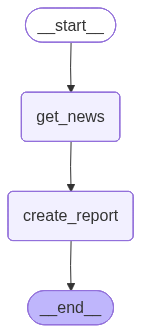

In [113]:
graph = StateGraph(NewsModel)

graph.add_node("get_news", get_news)
graph.add_node("create_report", create_report)

graph.add_edge(START, "get_news")
graph.add_edge("get_news", "create_report")
graph.add_edge("create_report", END)

news_graph = graph.compile()

from IPython.display import Image, display
Image(news_graph.get_graph().draw_mermaid_png())

In [ ]:
response = news_graph.invoke(NewsModel(
    topic = "Get me latest weather in Delhi",
    news = "",
    report = ""
))


AttributeError: 'dict' object has no attribute 'report'

In [122]:
show_markdowwn(response['report'])

Weather Report: Delhi-NCR                                                                                          
Date of Report: March 21, 2026                                                                                     
Reporting Period: March 20–26, 2026                                                                                

-------------------------------------------------------------------------------------------------------------------

Executive Summary                                                                                                  

Delhi is experiencing an unusual cold and wet spell in late March, marked by the coldest March day in six years on 
March 20. A persistent western disturbance has brought rainfall, cooler temperatures, and improved air quality.    
While partly cloudy conditions and a yellow alert for rain/gusty winds prevail today, temperatures are expected to 
rise steadily toward the end of the week, returning to typical late-March levels.                                  

-------------------------------------------------------------------------------------------------------------------

1. Recent Highlights (March 20, 2026)                                                                              

 • Temperature: Maximum of 21.7°C (9.6°C below normal), the coldest March day since 2020.                          
 • Conditions: Fog and low cloud cover.                                                                            
 • Air Quality: AQI at 94 (Satisfactory) – the cleanest air in approximately five months.                          

-------------------------------------------------------------------------------------------------------------------

2. Current Conditions & Forecast – March 21, 2026                                                                  

 • Weather: Partly cloudy skies with possibility of rain and thunderstorms.                                        
 • Alert: Yellow alert issued by IMD for rain and gusty winds across Delhi-NCR.                                    
 • Temperatures:                                                                                                   
    • Maximum: ~27°C                                                                                               
    • Minimum: ~14°C                                                                                               
 • Air Quality: Satisfactory (AQI ~94).                                                                            

-------------------------------------------------------------------------------------------------------------------

3. Upcoming Week Forecast                                                                                          

                                                                                                      
 Date       Conditions                               Max/Min (°C)  Notable Events                     
 ──────────────────────────────────────────────────────────────────────────────────────────────────── 
 Mar 22     Generally cloudy                         30° / 16°     No precipitation expected.         
 Mar 23     Cloudy with light rain/drizzle possible  31° / 17°     Scattered showers likely.          
 Mar 24–26  Partly cloudy, gradually warming         32° / 18°     Dry trend established by March 26. 
                                                                                                      

-------------------------------------------------------------------------------------------------------------------

4. Key Observations & Trends                                                                                       

 • Unusual March Wetness: The month has seen significantly higher rainfall than climatological averages,           
   contributing to:                                                                                                
    • Below-norm